# Spearman-Based Anomaly Detection for Federated Learning

Two complementary detection strategies, both using Spearman rank correlation on client SHAP vectors:

| Section | Method | Reference | Score |
|---------|--------|-----------|-------|
| **A** | Pairwise cross-client | All other clients | Mean Spearman with peers |
| **B** | Server-model reference | `server-model/reference_shap.npz` | Spearman vs global model |

In [39]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from itertools import combinations
from scipy import stats as scipy_stats
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# RUN_NAME  = "fedavg_mlp_bike-sharing_ep5_lr0.001_bs8_dirichlet_alpha0.5_attack_mpaf_lambda0.3"
RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3"
# RUN_NAME = "fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_label_flip_pf0.5_v1_t0"
BASE_PATH = Path("../experiments/shap_outputs") / RUN_NAME

print(f"Run : {RUN_NAME}")
print(f"Path: {BASE_PATH}")

Run : fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3
Path: ../experiments/shap_outputs/fedavg_mlp_adult-income-census_ep5_lr0.001_bs8_iid_attack_mpaf_lambda0.3


In [40]:
# ── Shared loaders ─────────────────────────────────────────────────────────────


def load_json(path):
    try:
        with open(path) as f:
            return json.load(f)
    except Exception:
        return {}


def load_npz_vector(path):
    """Load first array from npz and reduce to a 1-D per-feature vector."""
    try:
        z = np.load(path, allow_pickle=True)
        arr = np.asarray(z[list(z.keys())[0]])
        if arr.ndim == 0:
            return np.array([float(arr)])
        if arr.ndim == 1:
            return arr
        return np.mean(arr, axis=0)  # (n_samples, n_features) -> (n_features,)
    except Exception:
        return None


def spearman_corr(a, b):
    """Spearman rank correlation; returns 0.0 on NaN."""
    r, _ = scipy_stats.spearmanr(a, b)
    return float(r) if not np.isnan(r) else 0.0


print("Loaders defined.")

Loaders defined.


In [41]:
# ── Load server-model reference SHAP ──────────────────────────────────────────
server_ref_path = BASE_PATH / "server-model" / "reference_shap.npz"
server_shap_ref = load_npz_vector(server_ref_path)

if server_shap_ref is not None:
    print(f"Server reference SHAP loaded — shape: {server_shap_ref.shape}")
else:
    print("WARNING: server reference SHAP not found — check path.")

Server reference SHAP loaded — shape: (30,)


In [42]:
# ── Load all client SHAP vectors across rounds ─────────────────────────────────
client_data = defaultdict(dict)
round_dirs = sorted(
    [d for d in BASE_PATH.iterdir() if d.is_dir() and d.name.startswith("round_")]
)

print(f"Found {len(round_dirs)} rounds.")

for rdir in round_dirs:
    rnum = int(rdir.name.split("_")[1])
    for cdir in sorted([d for d in rdir.iterdir() if d.is_dir()]):
        cid = cdir.name
        meta = load_json(cdir / "metadata.json")
        sv = load_npz_vector(cdir / "shap_values.npz")
        if sv is None:
            continue
        if cid not in client_data:
            client_data[cid] = {
                "is_malicious": bool(
                    meta.get("malicious", meta.get("is_malicious", False))
                ),
                "rounds": {},
            }
        client_data[cid]["rounds"][rnum] = sv

n_mal = sum(1 for c in client_data.values() if c["is_malicious"])
n_ben = sum(1 for c in client_data.values() if not c["is_malicious"])
print(f"Clients loaded: {len(client_data)}  |  malicious: {n_mal}  |  benign: {n_ben}")

Found 30 rounds.
Clients loaded: 30  |  malicious: 6  |  benign: 24


---
# Section A: Pairwise Spearman (Cross-Client)

**Rationale:** For each client, compute the mean Spearman correlation with every other client in the same round.
A low mean correlation indicates that the client's SHAP feature-importance *ranking* diverges from the consensus — a strong signal of anomaly that is robust to magnitude differences caused by non-IID data.

**Score:** `mean_pairwise_spearman` — fully cross-client, produces a client-level score per round.

Detection rule: flag a client when its score is more than `Z_THRESH` standard deviations below the round mean.

In [43]:
Z_THRESH_A = 2.0  # flag if score < mu - Z_THRESH * sigma

all_rounds = sorted({r for c in client_data.values() for r in c["rounds"]})
records_A = []

for rnum in all_rounds:
    # Collect clients present this round
    clients_this_round = {
        cid: client_data[cid]["rounds"][rnum]
        for cid in client_data
        if rnum in client_data[cid]["rounds"]
    }
    if len(clients_this_round) < 3:
        continue  # need at least 3 for meaningful pairwise stats

    cids = list(clients_this_round.keys())
    vectors = [clients_this_round[c] for c in cids]

    # Full pairwise Spearman matrix (symmetric)
    n = len(cids)
    corr_matrix = np.eye(n)  # diagonal = 1 (self-correlation)
    for i, j in combinations(range(n), 2):
        r = spearman_corr(vectors[i], vectors[j])
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r

    # Mean correlation with all *other* clients (exclude diagonal)
    for i, cid in enumerate(cids):
        peers = [corr_matrix[i, j] for j in range(n) if j != i]
        mean_corr = float(np.mean(peers))
        records_A.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": client_data[cid]["is_malicious"],
                "mean_pairwise_sp": mean_corr,
            }
        )

df_A = pd.DataFrame(records_A)
print(
    f"[Section A] Records: {len(df_A)}  |  rounds: {df_A['round'].nunique()}  |  clients: {df_A['client'].nunique()}"
)
print()
print(df_A.groupby("is_malicious")["mean_pairwise_sp"].describe().T)

[Section A] Records: 900  |  rounds: 30  |  clients: 30

is_malicious       False       True 
count         720.000000  180.000000
mean            0.649235    0.225472
std             0.099145    0.198050
min            -0.191747   -0.165826
25%             0.643125    0.097870
50%             0.673708    0.188523
75%             0.694443    0.322327
max             0.729758    0.723048


In [44]:
# ── Per-round mean-based flagging (Section A) ──────────────────────────────────
round_stats_A = (
    df_A.groupby("round")["mean_pairwise_sp"]
    .agg(sp_mu=lambda x: x.mean())
    .reset_index()
)

# merge and flag when a client's mean pairwise Spearman is LESS THAN the round mean
df_A = df_A.merge(round_stats_A, on="round")
df_A["flagged"] = df_A["mean_pairwise_sp"] < df_A["sp_mu"]

print("Per-round flag counts (Section A):")
print(df_A.groupby("round")["flagged"].sum().rename("flagged_count").to_frame())

Per-round flag counts (Section A):
       flagged_count
round               
1                  6
2                  6
3                  8
4                  7
5                  6
6                  7
7                  7
8                  6
9                  7
10                 6
11                 7
12                 6
13                 6
14                 7
15                 6
16                 6
17                 6
18                 6
19                 6
20                 7
21                 6
22                 6
23                 6
24                 6
25                 6
26                 7
27                 7
28                 7
29                 8
30                 8


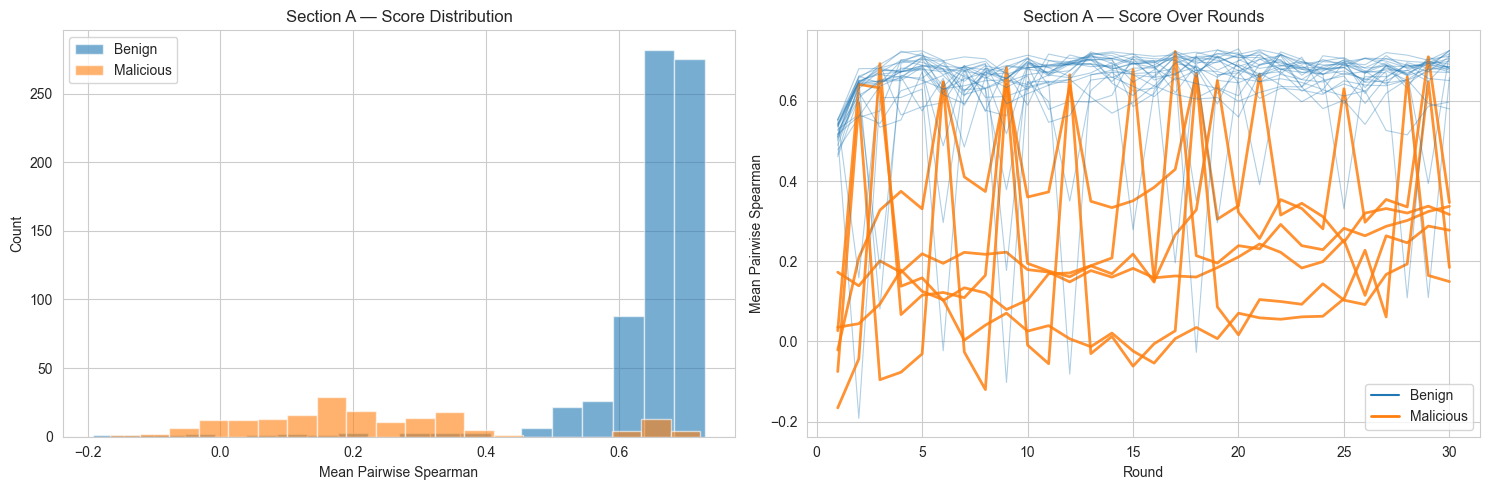

In [45]:
# ── Score distribution — box plot per client ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: distribution by ground truth
ax = axes[0]
for label, grp in df_A.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["mean_pairwise_sp"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Mean Pairwise Spearman")
ax.set_ylabel("Count")
ax.set_title("Section A — Score Distribution")
ax.legend()

# Right: score over rounds per client
ax = axes[1]
for cid, grp in df_A.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(
        grp["round"], grp["mean_pairwise_sp"], color=color, alpha=alpha, linewidth=lw
    )

legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("Mean Pairwise Spearman")
ax.set_title("Section A — Score Over Rounds")

plt.tight_layout()
plt.show()

/home/b-fatma/miniconda3/envs/flwr/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.draw()
/tmp/ipykernel_33534/727092079.py:29: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/home/b-fatma/miniconda3/envs/flwr/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


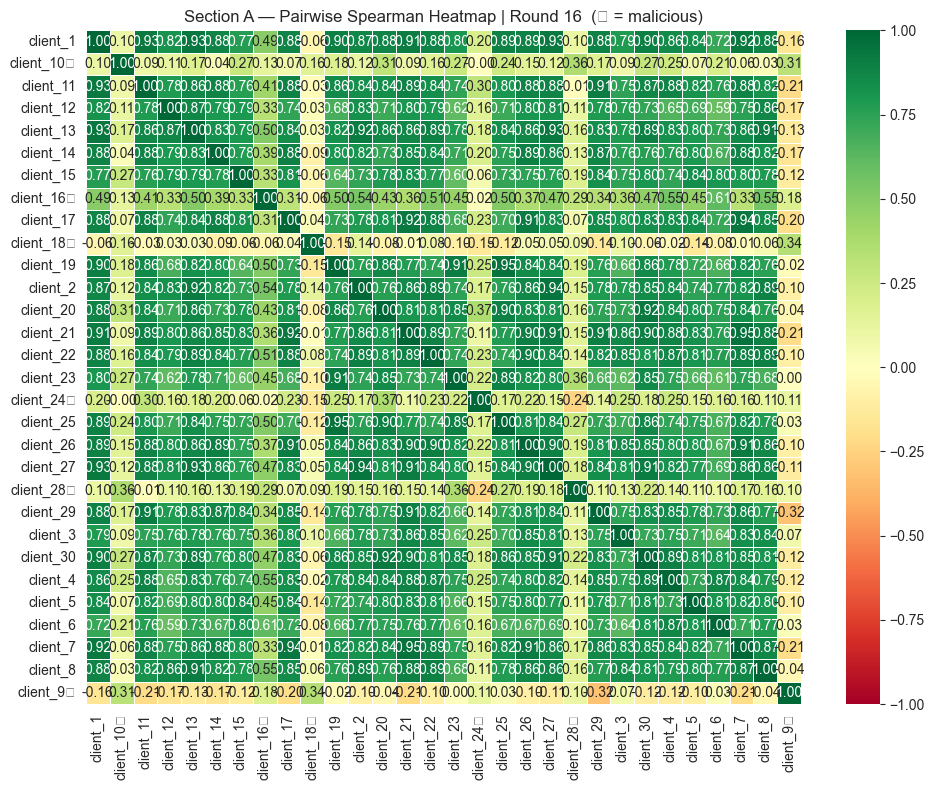

In [46]:
# ── Pairwise Spearman heatmap for a single representative round ────────────────
EXAMPLE_ROUND = all_rounds[len(all_rounds) // 2]  # pick middle round

clients_er = {
    cid: client_data[cid]["rounds"][EXAMPLE_ROUND]
    for cid in client_data
    if EXAMPLE_ROUND in client_data[cid]["rounds"]
}
cids_er = list(clients_er.keys())
vecs_er = [clients_er[c] for c in cids_er]
n_er = len(cids_er)
mat = np.eye(n_er)
for i, j in combinations(range(n_er), 2):
    r = spearman_corr(vecs_er[i], vecs_er[j])
    mat[i, j] = mat[j, i] = r

labels = [f"{cid}{'★' if client_data[cid]['is_malicious'] else ''}" for cid in cids_er]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    mat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title(
    f"Section A — Pairwise Spearman Heatmap | Round {EXAMPLE_ROUND}  (★ = malicious)"
)
plt.tight_layout()
plt.show()

In [47]:
# ── Client-level aggregation & classification ──────────────────────────────────
client_agg_A = (
    df_A.groupby("client")
    .agg(
        is_malicious=("is_malicious", "first"),
        mean_score=("mean_pairwise_sp", "mean"),
        min_score=("mean_pairwise_sp", "min"),
        flag_any=("flagged", "any"),
        flag_majority=("flagged", lambda x: x.mean() > 0.5),
        flag_rate=("flagged", "mean"),
    )
    .reset_index()
    .sort_values("mean_score")
)

print(
    "Client-level summary (Section A) — sorted by mean score (lowest = most suspicious):"
)
print(client_agg_A.to_string(index=False))

for rule, col in [
    ("ANY (>=1 round)", "flag_any"),
    ("MAJORITY (>50%)", "flag_majority"),
]:
    y_true = client_agg_A["is_malicious"].astype(int)
    y_pred = client_agg_A[col].astype(int)
    print(f"\n{'=' * 60}")
    print(f"Rule: {rule}")
    print(classification_report(y_true, y_pred, target_names=["benign", "malicious"]))
    cm = confusion_matrix(y_true, y_pred)
    print(
        pd.DataFrame(
            cm,
            index=["true_benign", "true_malicious"],
            columns=["pred_benign", "pred_malicious"],
        )
    )

Client-level summary (Section A) — sorted by mean score (lowest = most suspicious):
   client  is_malicious  mean_score  min_score  flag_any  flag_majority  flag_rate
 client_9          True    0.080583  -0.054170      True           True   0.966667
client_18          True    0.152637  -0.120217      True           True   0.800000
client_10          True    0.198097   0.114674      True           True   1.000000
client_28          True    0.238464  -0.165826      True           True   0.900000
client_24          True    0.305383   0.026651      True           True   0.800000
client_16          True    0.377666  -0.021507      True           True   0.833333
client_17         False    0.507091  -0.191747      True          False   0.200000
client_23         False    0.598732   0.181044      True          False   0.166667
 client_5         False    0.601161   0.487834      True          False   0.300000
client_15         False    0.602104   0.296232      True          False   0.166667
 cl

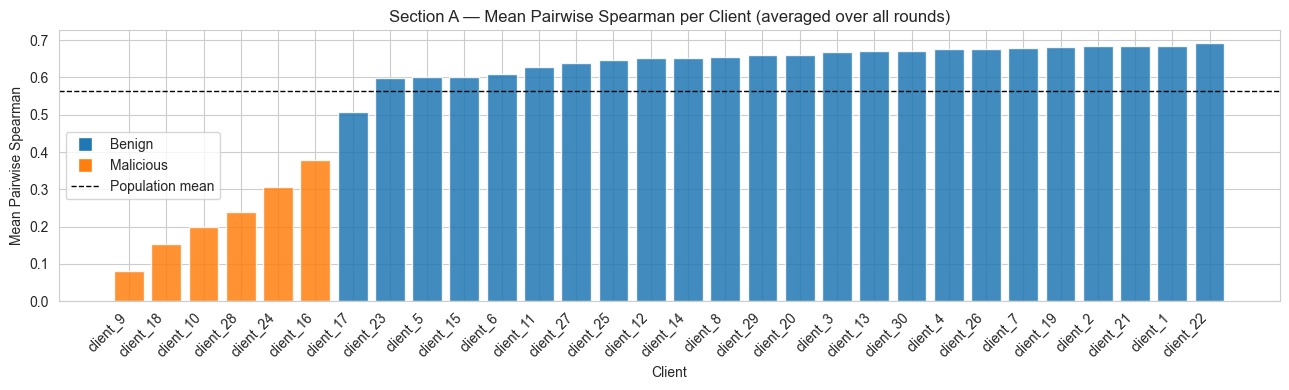

In [48]:
# ── Client-level bar chart: mean pairwise Spearman ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

colors = client_agg_A["is_malicious"].map({True: "tab:orange", False: "tab:blue"})
ax.bar(
    client_agg_A["client"],
    client_agg_A["mean_score"],
    color=colors,
    edgecolor="white",
    alpha=0.85,
)
ax.axhline(
    client_agg_A["mean_score"].mean(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Population mean",
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="tab:blue",
        markersize=10,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="tab:orange",
        markersize=10,
        label="Malicious",
    ),
    Line2D(
        [0], [0], color="black", linestyle="--", linewidth=1, label="Population mean"
    ),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Client")
ax.set_ylabel("Mean Pairwise Spearman")
ax.set_title("Section A — Mean Pairwise Spearman per Client (averaged over all rounds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
# Section B: Spearman vs Server-Model Reference

**Rationale:** Compare each client's SHAP vector against the global model's SHAP reference stored in `server-model/reference_shap.npz`.
This measures how closely a client's local feature-importance ranking aligns with the server's ground truth — a client that disagrees with the server's feature ranking may be injecting poisoned updates.

**Score:** `spearman_vs_server` — independent of other clients, sensitive to global model drift.

Detection rule: flag a client when its score is more than `Z_THRESH` standard deviations below the round mean.

In [49]:
Z_THRESH_B = 2.0

if server_shap_ref is None:
    raise RuntimeError(
        "Server reference SHAP not loaded. "
        "Check that BASE_PATH / 'server-model' / 'reference_shap.npz' exists."
    )

records_B = []

for rnum in all_rounds:
    clients_this_round = {
        cid: client_data[cid]["rounds"][rnum]
        for cid in client_data
        if rnum in client_data[cid]["rounds"]
    }
    if len(clients_this_round) < 2:
        continue

    for cid, sv in clients_this_round.items():
        records_B.append(
            {
                "round": rnum,
                "client": cid,
                "is_malicious": client_data[cid]["is_malicious"],
                "spearman_vs_server": spearman_corr(sv, server_shap_ref),
            }
        )

df_B = pd.DataFrame(records_B)
print(
    f"[Section B] Records: {len(df_B)}  |  rounds: {df_B['round'].nunique()}  |  clients: {df_B['client'].nunique()}"
)
print()
print(df_B.groupby("is_malicious")["spearman_vs_server"].describe().T)

[Section B] Records: 900  |  rounds: 30  |  clients: 30

is_malicious       False       True 
count         720.000000  180.000000
mean            0.610813    0.218219
std             0.127339    0.216694
min            -0.206413   -0.203295
25%             0.554220    0.026386
50%             0.633489    0.224894
75%             0.691939    0.340459
max             0.866399    0.736362


In [50]:
# ── Per-round mean-based flagging (Section B) ──────────────────────────────────
round_stats_B = (
    df_B.groupby("round")["spearman_vs_server"]
    .agg(sp_mu=lambda x: x.mean())
    .reset_index()
)

# merge and flag when a client's Spearman vs server is LESS THAN the round mean
df_B = df_B.merge(round_stats_B, on="round")
df_B["flagged"] = df_B["spearman_vs_server"] < df_B["sp_mu"]

print("Per-round flag counts (Section B):")
print(df_B.groupby("round")["flagged"].sum().rename("flagged_count").to_frame())

Per-round flag counts (Section B):
       flagged_count
round               
1                  9
2                  9
3                 10
4                 10
5                  7
6                  9
7                 10
8                  9
9                  8
10                 7
11                 8
12                 7
13                 8
14                10
15                10
16                 9
17                 9
18                10
19                10
20                10
21                 9
22                10
23                10
24                11
25                13
26                12
27                12
28                13
29                13
30                12


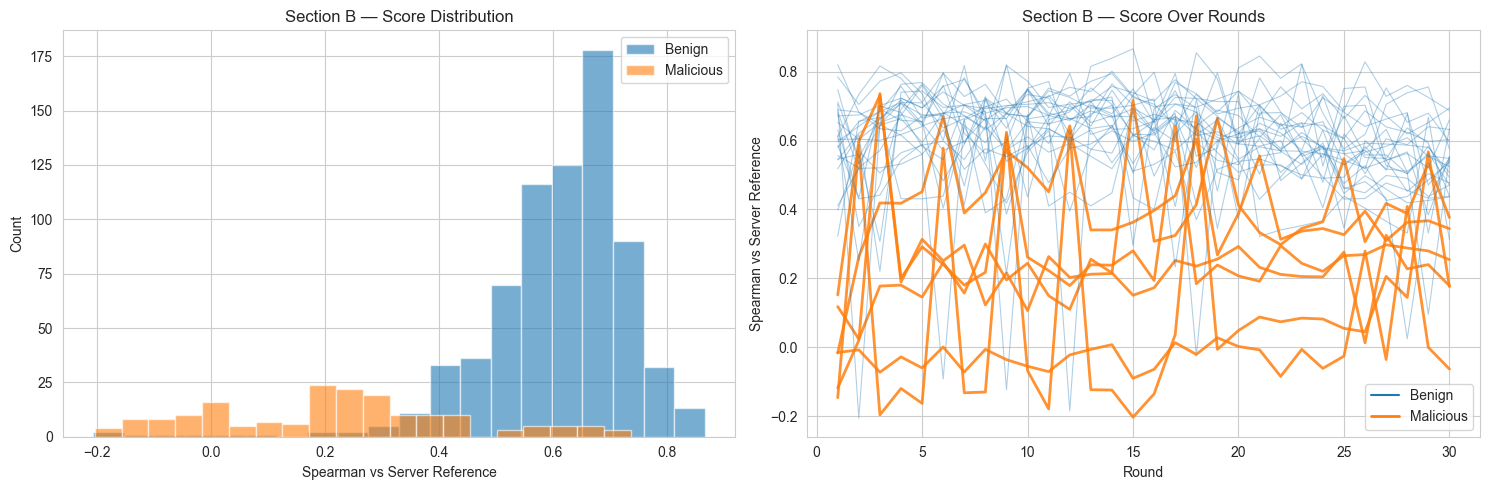

In [51]:
# ── Score distribution and evolution over rounds ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: histogram
ax = axes[0]
for label, grp in df_B.groupby("is_malicious"):
    color = "tab:orange" if label else "tab:blue"
    name = "Malicious" if label else "Benign"
    ax.hist(
        grp["spearman_vs_server"],
        bins=20,
        alpha=0.6,
        color=color,
        label=name,
        edgecolor="white",
    )
ax.set_xlabel("Spearman vs Server Reference")
ax.set_ylabel("Count")
ax.set_title("Section B — Score Distribution")
ax.legend()

# Right: score over rounds per client
ax = axes[1]
for cid, grp in df_B.groupby("client"):
    is_mal = grp["is_malicious"].iloc[0]
    color = "tab:orange" if is_mal else "tab:blue"
    alpha = 0.85 if is_mal else 0.35
    lw = 2.0 if is_mal else 0.8
    ax.plot(
        grp["round"], grp["spearman_vs_server"], color=color, alpha=alpha, linewidth=lw
    )

legend_elements = [
    Line2D([0], [0], color="tab:blue", linewidth=1.5, label="Benign"),
    Line2D([0], [0], color="tab:orange", linewidth=2.0, label="Malicious"),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Round")
ax.set_ylabel("Spearman vs Server Reference")
ax.set_title("Section B — Score Over Rounds")

plt.tight_layout()
plt.show()

In [52]:
# ── Client-level aggregation & classification ──────────────────────────────────
client_agg_B = (
    df_B.groupby("client")
    .agg(
        is_malicious=("is_malicious", "first"),
        mean_score=("spearman_vs_server", "mean"),
        min_score=("spearman_vs_server", "min"),
        flag_any=("flagged", "any"),
        flag_majority=("flagged", lambda x: x.mean() > 0.5),
        flag_rate=("flagged", "mean"),
    )
    .reset_index()
    .sort_values("mean_score")
)

print(
    "Client-level summary (Section B) — sorted by mean score (lowest = most suspicious):"
)
print(client_agg_B.to_string(index=False))

for rule, col in [
    ("ANY (>=1 round)", "flag_any"),
    ("MAJORITY (>50%)", "flag_majority"),
]:
    y_true = client_agg_B["is_malicious"].astype(int)
    y_pred = client_agg_B[col].astype(int)
    print(f"\n{'=' * 60}")
    print(f"Rule: {rule}")
    print(classification_report(y_true, y_pred, target_names=["benign", "malicious"]))
    cm = confusion_matrix(y_true, y_pred)
    print(
        pd.DataFrame(
            cm,
            index=["true_benign", "true_malicious"],
            columns=["pred_benign", "pred_malicious"],
        )
    )

Client-level summary (Section B) — sorted by mean score (lowest = most suspicious):
   client  is_malicious  mean_score  min_score  flag_any  flag_majority  flag_rate
 client_9          True   -0.005982  -0.090626      True           True   1.000000
client_18          True    0.098790  -0.203295      True           True   0.800000
client_10          True    0.199540   0.012692      True           True   1.000000
client_28          True    0.262421  -0.118682      True           True   0.900000
client_24          True    0.353863   0.106212      True           True   0.800000
client_16          True    0.400683  -0.017145      True           True   0.833333
client_11         False    0.479804   0.312403      True           True   0.700000
client_17         False    0.488904  -0.206413      True          False   0.200000
client_15         False    0.522972   0.370296      True           True   0.600000
client_13         False    0.543071   0.398352      True          False   0.500000
 cl

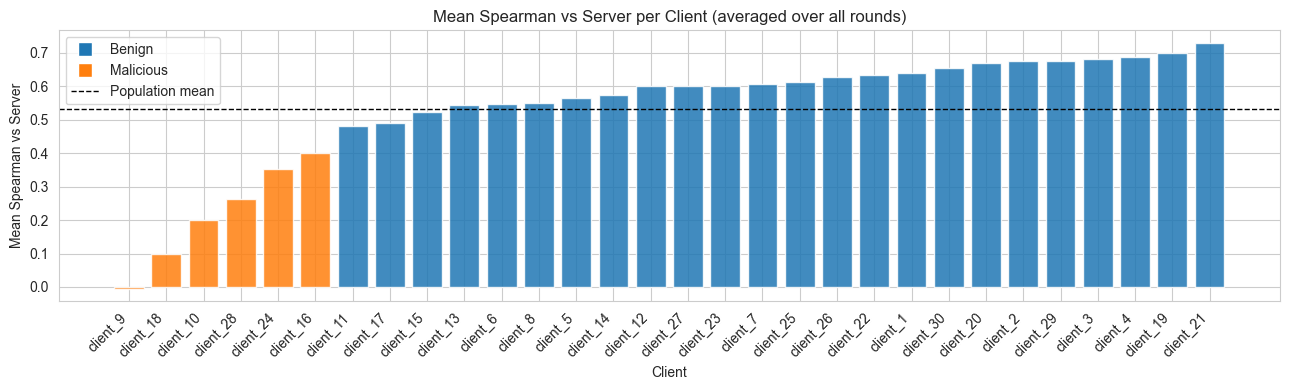

In [53]:
# ── Client-level bar chart: mean Spearman vs server ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

colors = client_agg_B["is_malicious"].map({True: "tab:orange", False: "tab:blue"})
ax.bar(
    client_agg_B["client"],
    client_agg_B["mean_score"],
    color=colors,
    edgecolor="white",
    alpha=0.85,
)
ax.axhline(
    client_agg_B["mean_score"].mean(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Population mean",
)

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="tab:blue",
        markersize=10,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="tab:orange",
        markersize=10,
        label="Malicious",
    ),
    Line2D(
        [0], [0], color="black", linestyle="--", linewidth=1, label="Population mean"
    ),
]
ax.legend(handles=legend_elements)
ax.set_xlabel("Client")
ax.set_ylabel("Mean Spearman vs Server")
ax.set_title("Mean Spearman vs Server per Client (averaged over all rounds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
# Section A vs B — Side-by-Side Comparison

Overlay both scores at the client level to see whether the two methods agree and where they diverge.

In [54]:
# ── Merge client-level aggregates ─────────────────────────────────────────────
comparison = client_agg_A[
    ["client", "is_malicious", "mean_score", "flag_any", "flag_majority"]
].copy()
comparison = comparison.rename(
    columns={
        "mean_score": "score_A_pairwise",
        "flag_any": "flagged_A_any",
        "flag_majority": "flagged_A_maj",
    }
)
comparison = comparison.merge(
    client_agg_B[["client", "mean_score", "flag_any", "flag_majority"]].rename(
        columns={
            "mean_score": "score_B_server",
            "flag_any": "flagged_B_any",
            "flag_majority": "flagged_B_maj",
        }
    ),
    on="client",
)

print("Combined client-level view:")
print(comparison.to_string(index=False))

Combined client-level view:
   client  is_malicious  score_A_pairwise  flagged_A_any  flagged_A_maj  score_B_server  flagged_B_any  flagged_B_maj
 client_9          True          0.080583           True           True       -0.005982           True           True
client_18          True          0.152637           True           True        0.098790           True           True
client_10          True          0.198097           True           True        0.199540           True           True
client_28          True          0.238464           True           True        0.262421           True           True
client_24          True          0.305383           True           True        0.353863           True           True
client_16          True          0.377666           True           True        0.400683           True           True
client_17         False          0.507091           True          False        0.488904           True          False
client_23         False     

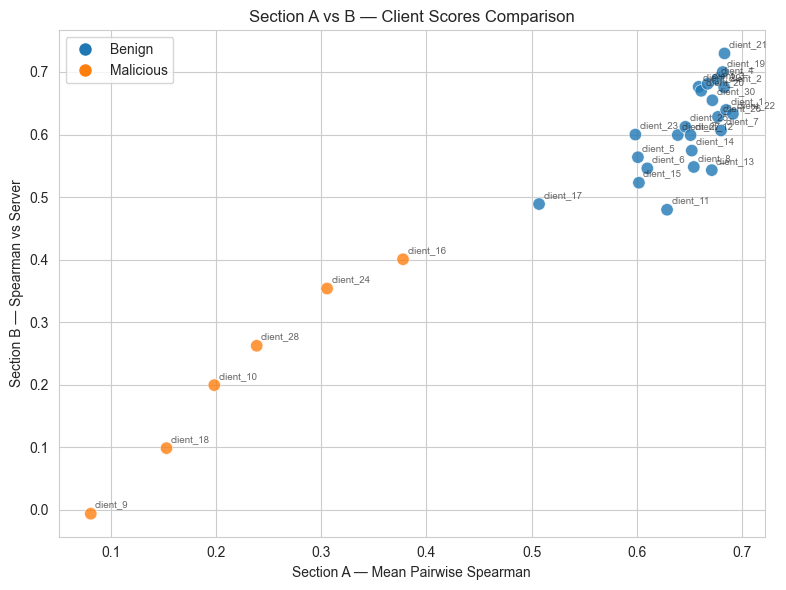

In [55]:
# ── Scatter: Section A score vs Section B score ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = comparison["is_malicious"].map({True: "tab:orange", False: "tab:blue"})
ax.scatter(
    comparison["score_A_pairwise"],
    comparison["score_B_server"],
    c=colors,
    s=80,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)

# Annotate client IDs
for _, row in comparison.iterrows():
    ax.annotate(
        row["client"],
        (row["score_A_pairwise"], row["score_B_server"]),
        fontsize=7,
        ha="left",
        va="bottom",
        xytext=(3, 3),
        textcoords="offset points",
        alpha=0.7,
    )

ax.set_xlabel("Section A — Mean Pairwise Spearman")
ax.set_ylabel("Section B — Spearman vs Server")
ax.set_title("Section A vs B — Client Scores Comparison")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:blue",
        markersize=10,
        label="Benign",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="tab:orange",
        markersize=10,
        label="Malicious",
    ),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [56]:
# ── Agreement table: how often do A and B agree on the flag? ──────────────────
comparison["agree_any"] = comparison["flagged_A_any"] == comparison["flagged_B_any"]
comparison["agree_maj"] = comparison["flagged_A_maj"] == comparison["flagged_B_maj"]

print(
    f"Flag agreement (ANY rule):      {comparison['agree_any'].mean():.0%} of clients"
)
print(
    f"Flag agreement (MAJORITY rule): {comparison['agree_maj'].mean():.0%} of clients"
)
print()

# Ensemble: flag if BOTH methods agree the client is suspicious
for rule, col_A, col_B in [
    ("AND-ANY", "flagged_A_any", "flagged_B_any"),
    ("AND-MAJORITY", "flagged_A_maj", "flagged_B_maj"),
    ("OR-ANY", "flagged_A_any", "flagged_B_any"),
    ("OR-MAJORITY", "flagged_A_maj", "flagged_B_maj"),
]:
    if rule.startswith("AND"):
        y_pred = (comparison[col_A] & comparison[col_B]).astype(int)
    else:
        y_pred = (comparison[col_A] | comparison[col_B]).astype(int)
    y_true = comparison["is_malicious"].astype(int)
    print(f"{'=' * 60}")
    print(f"Ensemble: {rule}")
    print(classification_report(y_true, y_pred, target_names=["benign", "malicious"]))
    cm = confusion_matrix(y_true, y_pred)
    print(
        pd.DataFrame(
            cm,
            index=["true_benign", "true_malicious"],
            columns=["pred_benign", "pred_malicious"],
        )
    )

Flag agreement (ANY rule):      67% of clients
Flag agreement (MAJORITY rule): 93% of clients

Ensemble: AND-ANY
              precision    recall  f1-score   support

      benign       1.00      0.62      0.77        24
   malicious       0.40      1.00      0.57         6

    accuracy                           0.70        30
   macro avg       0.70      0.81      0.67        30
weighted avg       0.88      0.70      0.73        30

                pred_benign  pred_malicious
true_benign              15               9
true_malicious            0               6
Ensemble: AND-MAJORITY
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00        24
   malicious       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

                pred_benign  pred_malicious
true_benign              24       